# FinLora Fraud Detection Project
## 02 — Data Profiling

### Objective

The objective of this notebook is to systematically assess the quality, structure, and statistical characteristics of the FinLora transaction dataset before data cleaning and feature engineering.

The profiling process will examine:

- Dataset size and structure
- Missing values
- Duplicate transaction records
- Numerical variables and unusual values
- Categorical consistency
- Data types and datetime fields
- Transaction amount distributions
- Fraud and legitimate transaction distributions
- Class imbalance
- Identifier uniqueness
- Potential data leakage
- Overall data quality issues requiring attention

No permanent data cleaning or transformation will be performed in this notebook. The purpose is to identify, quantify, and document issues that will inform the subsequent Data Cleaning stage.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Dataset"
    / "raw"
    / "FinLora_Customer_Transaction_Dataset.csv"
)

df = pd.read_csv(DATA_PATH)

df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


## 1. Dataset Size and Structure

The first profiling step examines the dimensions and structural characteristics of the supplied dataset.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 11,400
Columns: 26


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,11400,11200,805e3831-dd30-44cd-9db8-122425ec3a36,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,11400,1315,402cccc9-28de-45b3-9af7-cc5302aa1f93,1510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,11371,11141,0000-00-00T00:00:00Z,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_country,11400,7,US,7940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_currency,11400,3,USD,8031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_currency,11400,9,NGN,1474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,11400,12,mobile,6366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_src,11400,9856,100.0,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_usd,11095.0,NaN,NaN,NaN,452.022083,1403.973062,7.23,92.465,163.48,302.19,12498.57
fee,11105.0,NaN,NaN,NaN,100.309441,958.128504,-1.0,2.38,3.5,5.55,9999.99


## 2. Missing Value Analysis

Missing values can affect statistical analysis, feature engineering, and machine learning model performance. This section identifies the number and proportion of missing observations across the dataset.

In [6]:
# Summary of columns with missing values
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percentage
amount_usd,305,2.675439
ip_address,305,2.675439
ip_country,301,2.640351
kyc_tier,300,2.631579
device_trust_score,295,2.587719
fee,295,2.587719
timestamp,29,0.254386
transaction_id,0,0.000000
customer_id,0,0.000000
home_country,0,0.000000


In [7]:
# To show only columns with missing values
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
amount_usd,305,2.675439
ip_address,305,2.675439
ip_country,301,2.640351
kyc_tier,300,2.631579
device_trust_score,295,2.587719
fee,295,2.587719
timestamp,29,0.254386


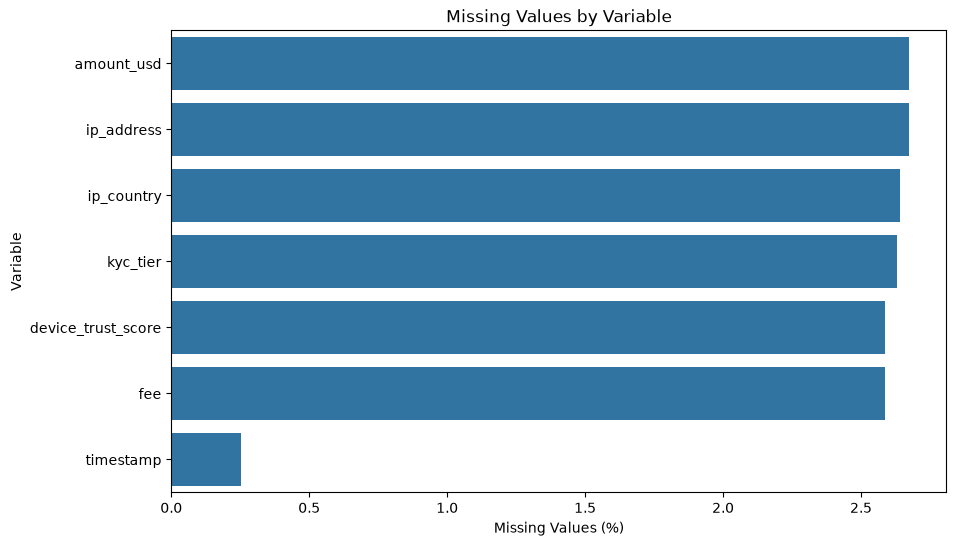

In [8]:
# To visualize the missimgness

missing_summary_nonzero = (
    missing_summary[missing_summary["missing_count"] > 0]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_summary_nonzero["missing_percentage"],
    y=missing_summary_nonzero.index
)

plt.title("Missing Values by Variable")
plt.xlabel("Missing Values (%)")
plt.ylabel("Variable")
plt.show()

### Summary of findings on missingess

* Standard .isnull() checks show timestamp with 29 missing values. 
* However, deeper validation (attempting to parse every value as a real date) reveals an additional 32 rows containing syntactically invalid or placeholder timestamp text (e.g. "0000-00-00T00:00:00Z", "2025/13/40 25:61:00") that are not caught by .isnull() but are equally unusable. 
* The true count of missing-or-invalid timestamps is 61, not 29. 
* This is the third instance in this dataset of missingness being disguised in a form that evades naive null-checking.

## 3. Duplicate Record Analysis

Duplicate records can distort transaction counts, fraud rates, model training, and evaluation results. The dataset is therefore examined for both fully duplicated rows and repeated transaction identifiers.

In [9]:
# ------------------------------------------------------------------
# STEP 1: Check for fully duplicated rows
# ------------------------------------------------------------------
# duplicated() flags rows that are IDENTICAL to an earlier row across
# every single column. .sum() counts how many such rows exist.

exact_duplicates = df.duplicated().sum()
print("Fully duplicated rows (identical across all columns):", exact_duplicates)

Fully duplicated rows (identical across all columns): 200


In [10]:
# ------------------------------------------------------------------
# STEP 2: Check for duplicated transaction IDs specifically
# ------------------------------------------------------------------
# This re-confirms the Data Understanding finding: 200 transaction_ids
# appear exactly twice each. We check this directly here so the
# Profiling notebook doesn't depend on trusting an earlier notebook's
# numbers without verification.

duplicate_id_counts = df["transaction_id"].value_counts()
duplicated_ids = duplicate_id_counts[duplicate_id_counts > 1]

print("Number of transaction_ids that appear more than once:", len(duplicated_ids))
print("\nFrequency breakdown (how many times each duplicated ID appears):")
print(duplicated_ids.value_counts())

Number of transaction_ids that appear more than once: 200

Frequency breakdown (how many times each duplicated ID appears):
count
2    200
Name: count, dtype: int64


In [11]:
# ------------------------------------------------------------------
# STEP 3: Confirm these duplicate ID groups are still exact duplicates
# ------------------------------------------------------------------
# Data Understanding already confirmed this, but we re-verify directly:
# for a sample of duplicated transaction_ids, are the two rows truly
# identical across every column, or do they differ anywhere?

sample_duplicate_id = duplicated_ids.index[0]
duplicate_pair = df[df["transaction_id"] == sample_duplicate_id]

print(f"Comparing the two rows for transaction_id = {sample_duplicate_id}:")
print(duplicate_pair)

# Check which columns (if any) differ between this pair
differing_cols = duplicate_pair.nunique()
differing_cols = differing_cols[differing_cols > 1]
print("\nColumns that differ between this duplicate pair:", list(differing_cols.index))

Comparing the two rows for transaction_id = 805e3831-dd30-44cd-9db8-122425ec3a36:
                             transaction_id  \
2474   805e3831-dd30-44cd-9db8-122425ec3a36   
10059  805e3831-dd30-44cd-9db8-122425ec3a36   

                                customer_id                         timestamp  \
2474   70a93d26-8e3a-4179-900c-a4a7a74d08e5  2023-07-03 21:49:10.468549+00:00   
10059  70a93d26-8e3a-4179-900c-a4a7a74d08e5  2023-07-03 21:49:10.468549+00:00   

      home_country source_currency dest_currency channel amount_src  \
2474            US             USD           PHP     web     290.55   
10059           US             USD           PHP     web     290.55   

       amount_usd   fee  ...  ip_risk_score  kyc_tier  account_age_days  \
2474       290.55  3.81  ...          0.197  enhanced               257   
10059      290.55  3.81  ...          0.197  enhanced               257   

      device_trust_score chargeback_history_count  risk_score_internal  \
2474              

## 4. Profiling of numerical variables and Unusual values

In [12]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_columns

Index(['amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score',
       'account_age_days', 'device_trust_score', 'chargeback_history_count',
       'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
       'corridor_risk', 'is_fraud'],
      dtype='object')

In [13]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd,11095.0,452.022083,1403.973062,7.230,92.465,163.480000,302.190000,12498.570000
fee,11105.0,100.309441,958.128504,-1.000,2.380,3.500000,5.550000,9999.990000
exchange_rate_src_to_dest,11400.0,167.540397,382.023827,0.592,1.000,7.142857,73.529412,1388.888889
ip_risk_score,11400.0,0.396726,0.270507,0.004,0.209,0.325000,0.487000,1.200000
account_age_days,11400.0,393.793158,342.348393,1.000,147.000,298.000000,661.000000,1095.000000
device_trust_score,11105.0,0.653681,0.273012,-0.100,0.515,0.658000,0.894000,0.999000
chargeback_history_count,11400.0,0.048509,0.256194,0.000,0.000,0.000000,0.000000,2.000000
risk_score_internal,11400.0,0.267134,0.142983,0.000,0.169,0.223000,0.391000,0.900000
txn_velocity_1h,11400.0,0.458333,1.524494,-1.000,0.000,0.000000,0.000000,8.000000
txn_velocity_24h,11400.0,0.723509,1.958390,0.000,0.000,0.000000,0.000000,11.000000


In [14]:
## To check for unusaul numeric values, first for where the values are negative

negative_value_summary = (
    df[numeric_columns] < 0
).sum()

negative_value_summary[
    negative_value_summary > 0
]

fee                   101
device_trust_score    204
txn_velocity_1h       204
dtype: int64

In [15]:
## Then we equally check for when the values are equal to zero

zero_value_summary = (
    df[numeric_columns] == 0
).sum()

zero_value_summary[
    zero_value_summary > 0
]

chargeback_history_count    10958
risk_score_internal            11
txn_velocity_1h              9970
txn_velocity_24h             9248
corridor_risk                8479
is_fraud                    10403
dtype: int64

## Transaction amount analysis

In [16]:
df["amount_usd"].describe()

count    11095.000000
mean       452.022083
std       1403.973062
min          7.230000
25%         92.465000
50%        163.480000
75%        302.190000
max      12498.570000
Name: amount_usd, dtype: float64

## To check generally for outliers across the numeric columns

In [17]:
# ------------------------------------------------------------------
# STEP 1: Identify which columns are numeric
# ------------------------------------------------------------------
# select_dtypes() lets us pick out only the columns pandas recognizes
# as numbers (int64 and float64). This excludes text/object columns
# and boolean columns, since summary stats like mean/std don't make
# sense for those.
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print the list so we can visually confirm which columns we're about
# to profile. This is a sanity check step, not a permanent change.
print("Numeric columns found:")
print(numeric_cols)

Numeric columns found:
['amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud']


In [18]:

#  ------------------------------------------------------------------
# STEP 1: Define a reusable function to detect outliers using IQR
# ------------------------------------------------------------------
# The IQR method works like this:
#   1. Find Q1 (25th percentile) and Q3 (75th percentile)
#   2. IQR = Q3 - Q1  (this measures the "spread" of the middle 50% of data)
#   3. Anything below (Q1 - 1.5 * IQR) or above (Q3 + 1.5 * IQR)
#      is considered a statistical outlier.
#
# 1.5 is a widely used standard multiplier (not something we invented).

def count_outliers_iqr(column: pd.Series):
    """
    Takes a single numeric column (pandas Series) and returns:
    - the number of outliers
    - the lower and upper bounds used to define an outlier
    """
    # Drop missing values first, since NaN would break the comparisons
    clean_column = column.dropna()

    # Calculate Q1 and Q3
    q1 = clean_column.quantile(0.25)
    q3 = clean_column.quantile(0.75)

    # Calculate the IQR (spread of the middle 50%)
    iqr = q3 - q1

    # Calculate the lower and upper "fences"
    # Anything outside this range is flagged as an outlier
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count how many values fall outside the bounds
    outliers = clean_column[(clean_column < lower_bound) | (clean_column > upper_bound)]

    return len(outliers), lower_bound, upper_bound

In [19]:
# ------------------------------------------------------------------
# STEP 2: Apply the function to every numeric column
# ------------------------------------------------------------------
# We loop through each numeric column, run our outlier function,
# and store the results in a list so we can turn it into a summary
# table at the end.

outlier_results = []

for col in numeric_cols:
    outlier_count, lower, upper = count_outliers_iqr(df[col])

    outlier_results.append({
        "column": col,
        "outlier_count": outlier_count,
        "lower_bound": lower,
        "upper_bound": upper
    })

# Convert the list of results into a clean DataFrame for easy viewing
outlier_summary = pd.DataFrame(outlier_results).sort_values(
    by="outlier_count", ascending=False
)

outlier_summary

,column,outlier_count,lower_bound,upper_bound
9,txn_velocity_24h,2152,0.000000,0.00000
10,corridor_risk,1736,-0.075000,0.12500
2,exchange_rate_src_to_dest,1474,-107.794118,182.32353
8,txn_velocity_1h,1430,0.000000,0.00000
3,ip_risk_score,1145,-0.208000,0.90400
1,fee,1087,-2.375000,10.30500
0,amount_usd,1043,-222.122500,616.77750
11,is_fraud,997,0.000000,0.00000
6,chargeback_history_count,442,0.000000,0.00000
7,risk_score_internal,234,-0.164000,0.72400


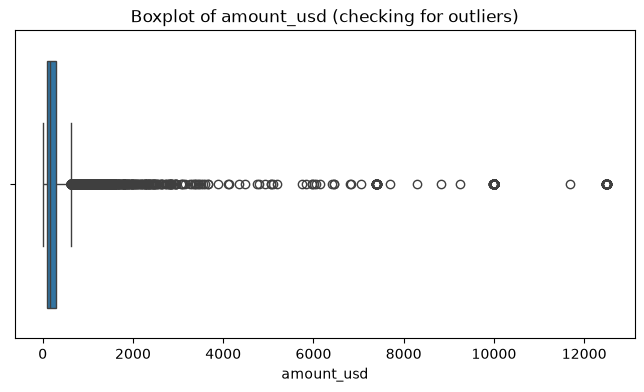

In [20]:
# ------------------------------------------------------------------
# To Visualize outliers with boxplots
# ------------------------------------------------------------------
# A boxplot is a quick visual way to see the same thing the IQR
# calculation showed us numerically: the box shows Q1-Q3 (middle 50%
# of data), the line inside is the median, and any dots outside the
# "whiskers" are the outliers.

import matplotlib.pyplot as plt
import seaborn as sns

# We'll plot one column at a time to keep it readable.
# Start with amount_usd since transaction amount is a key fraud-related variable.
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["amount_usd"])
plt.title("Boxplot of amount_usd (checking for outliers)")
plt.show()

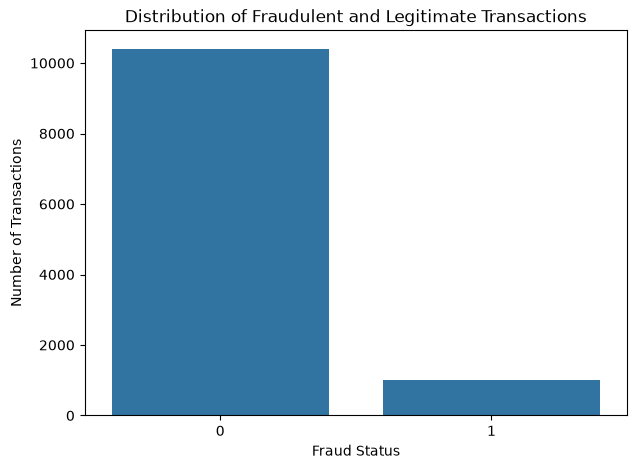

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")
plt.show()

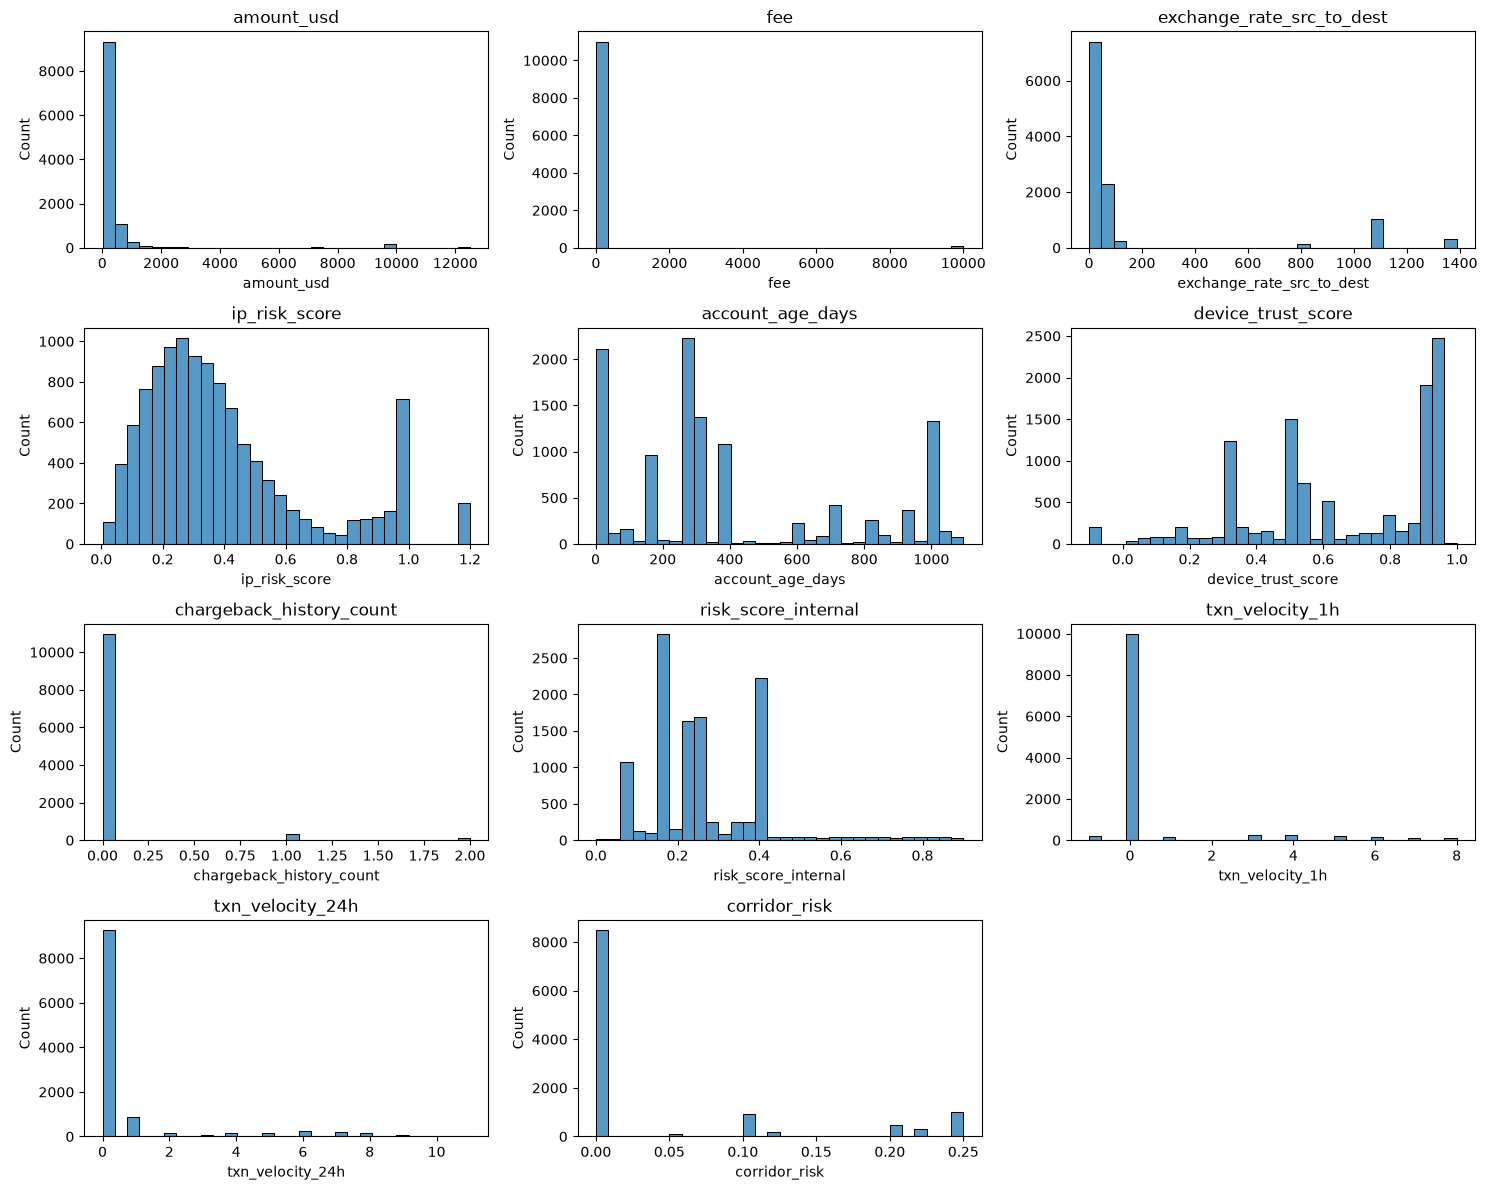

In [22]:
# ------------------------------------------------------------------
# Visualize the shape of each numeric variable with histograms
# ------------------------------------------------------------------
# Histograms show us how values are distributed - are they spread out
# evenly, clustered near zero, skewed to one side, etc. This helps us
# judge whether the IQR outlier counts above make sense or are
# artifacts of a skewed/zero-inflated distribution.

# Exclude is_fraud - it's our binary target, not a feature to profile
cols_to_plot = [c for c in numeric_cols if c != "is_fraud"]

# Set up a grid of small plots, one per column
n_cols = 3
n_rows = -(-len(cols_to_plot) // n_cols)  # rounds up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()  # makes it easier to loop through, regardless of grid shape

for i, col in enumerate(cols_to_plot):
    # bins=30 splits the range into 30 buckets - a reasonable default
    # for spotting shape without being too noisy or too coarse
    sns.histplot(df[col].dropna(), bins=30, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot slots (if grid has more slots than columns)
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------------
# Check exact min/max values for columns where the histogram suggested
# possible out-of-range or invalid values
# ------------------------------------------------------------------
# We use .min() and .max() to get the precise smallest and largest
# values in each column - this confirms (or rules out) what we think
# we saw visually in the histograms.

columns_to_check = ["ip_risk_score", "txn_velocity_1h", "device_trust_score"]

for col in columns_to_check:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

ip_risk_score: min = 0.004, max = 1.2
txn_velocity_1h: min = -1, max = 8
device_trust_score: min = -0.1, max = 0.999


In [24]:
# ------------------------------------------------------------------
# Count how many rows actually fall outside the expected valid range
# ------------------------------------------------------------------
# For ip_risk_score and device_trust_score, we're assuming they should
# logically fall between 0 and 1 (typical for a "score"). We're
# checking, not assuming this is definitely the intended range - this
# assumption should be noted clearly when we document the finding.

invalid_ip_risk = df[(df["ip_risk_score"] < 0) | (df["ip_risk_score"] > 1)]
invalid_device_trust = df[(df["device_trust_score"] < 0) | (df["device_trust_score"] > 1)]

# txn_velocity should logically never be negative, since it's a count
invalid_velocity_1h = df[df["txn_velocity_1h"] < 0]

print("Rows with ip_risk_score outside [0,1]:", len(invalid_ip_risk))
print("Rows with device_trust_score outside [0,1]:", len(invalid_device_trust))
print("Rows with negative txn_velocity_1h:", len(invalid_velocity_1h))

Rows with ip_risk_score outside [0,1]: 204
Rows with device_trust_score outside [0,1]: 204
Rows with negative txn_velocity_1h: 204


In [25]:
# ------------------------------------------------------------------
# Check whether the "invalid" rows in each column are the SAME rows
# ------------------------------------------------------------------
# If the same 204 rows are invalid across all three columns, that
# suggests a systematic data issue (e.g. one bad batch/source),
# rather than three unrelated random errors. We check this using
# set intersection on the row indexes.

invalid_ip_risk_idx = set(df[(df["ip_risk_score"] < 0) | (df["ip_risk_score"] > 1)].index)
invalid_device_trust_idx = set(df[(df["device_trust_score"] < 0) | (df["device_trust_score"] > 1)].index)
invalid_velocity_idx = set(df[df["txn_velocity_1h"] < 0].index)

# Intersection tells us how many rows appear in ALL three invalid sets
common_rows = invalid_ip_risk_idx & invalid_device_trust_idx & invalid_velocity_idx

print("Rows invalid in ip_risk_score:", len(invalid_ip_risk_idx))
print("Rows invalid in device_trust_score:", len(invalid_device_trust_idx))
print("Rows invalid in txn_velocity_1h:", len(invalid_velocity_idx))
print("Rows invalid in ALL THREE columns:", len(common_rows))

Rows invalid in ip_risk_score: 204
Rows invalid in device_trust_score: 204
Rows invalid in txn_velocity_1h: 204
Rows invalid in ALL THREE columns: 204


In [26]:
# ------------------------------------------------------------------
# If the rows overlap, inspect a sample of them directly
# ------------------------------------------------------------------
# Looking at the actual rows (not just counts) can reveal patterns -
# e.g. do they share the same channel, ip_country, device_id pattern,
# or timestamp range? This helps us figure out WHY these rows are
# invalid, not just THAT they are invalid.

if len(common_rows) > 0:
    sample_invalid_rows = df.loc[list(common_rows)].head(10)
    display(sample_invalid_rows)
else:
    print("The invalid rows are NOT the same across all three columns - investigate separately.")

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
8194,e6883819-11bd-4c4f-8bf5-6eb11243ae19,23d9943d-57b1-42eb-9ef2-05eed7fd1957,2025-03-23 09:44:21.468549+00:00,UK,GBP,GBP,mobile,-60.45,75.56,9999.99,...,1.2,standard,718,-0.1,0,0.169,-1,0,0.0,0
2563,f8f0cc8a-ce21-455f-b0ec-facc241c4be7,7bd5200c-5d19-44f0-9afe-8b339a05366b,2023-07-13 19:10:33.468549+00:00,US,USD,EUR,ATM,26.04,26.04,-1.00,...,1.2,standard,147,-0.1,0,0.391,-1,0,0.0,0
3088,5a0df69e-1200-4cd0-94b1-7f527bd9bdef,e40c2805-be81-40c7-acb7-b2407ff3b899,2023-09-13 09:45:39.468549+00:00,US,USD,GBP,mobile,223.82,NaN,-1.00,...,1.2,NaN,962,-0.1,0,0.147,-1,0,0.0,0
3601,0a82f85c-9172-4159-8739-d60ce5637210,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2023-11-07 07:56:19.468549+00:00,CA,CAD,NGN,web,-269.29,199.27,9999.99,...,1.2,standard,947,-0.1,0,0.268,-1,0,0.0,0
8211,473ea072-5750-4607-88c5-084e5d7c0d6d,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-03-25 08:16:42.468549+00:00,US,USD,CAD,mobile,-558.27,558.27,9999.99,...,1.2,standard,263,-0.1,0,0.223,-1,0,0.0,0
5656,b5d38327-435e-4fab-a17b-5d4f63b14fc2,7bd5200c-5d19-44f0-9afe-8b339a05366b,2024-06-08 19:23:55.468549+00:00,US,USD,CAD,mobile,360.16,360.16,-1.00,...,1.2,standard,147,-0.1,0,0.391,-1,0,0.0,0
9245,291734dd-53e5-4e6e-a8bc-1bf714ff99a1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2025-07-13 14:28:26.468549+00:00,CA,CAD,NGN,web,-125.82,93.11,9999.99,...,1.2,standard,947,-0.1,0,0.268,-1,0,0.0,0
4645,aa14d499-8a24-4397-ac59-94b63dae63b4,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2024-02-24 00:12:05.468549+00:00,UK,GBP,GBP,ATM,-435.1,543.88,9999.99,...,1.2,standard,4,-0.1,0,0.407,-1,0,0.0,0
5158,3adca318-50a0-4959-af26-6034f56866f0,07581610-391c-4938-acf4-39c7c272fc39,2024-04-15 07:14:10.468549+00:00,US,USD,PHP,ATM,-724.24,724.24,9999.99,...,1.2,standard,638,-0.1,0,0.244,-1,0,0.1,0
4648,576f756b-f24d-4021-a845-0665da43977f,140d2232-ee97-4934-81aa-9e5c323d7c6f,2024-02-24 04:14:49.468549+00:00,CA,CAD,MXN,mobile,172.71,127.81,-1.00,...,1.2,low,824,-0.1,0,0.282,-1,0,0.0,0


In [27]:
# ------------------------------------------------------------------
# Pull out the full set of 204 "invalid" rows for closer inspection
# ------------------------------------------------------------------
# We already found these row numbers (common_rows) in the last step.
# Now we look at them as a whole group, not just a 10-row sample.

suspect_rows = df.loc[list(common_rows)]

# Check 1: What values does 'fee' actually take across these 204 rows?
# value_counts() tells us how many times each unique value appears.
print("fee values among suspect rows:")
print(suspect_rows["fee"].value_counts())

fee values among suspect rows:
fee
 9999.99    103
-1.00       101
Name: count, dtype: int64


In [28]:
# ------------------------------------------------------------------
# Check 2: Compare missingness rate INSIDE vs OUTSIDE the suspect rows
# ------------------------------------------------------------------
# If these 204 rows are a "bad batch," we'd expect them to also have
# more missing values in OTHER columns compared to normal rows.
# We compare the percentage of missing values in each group.

# All rows NOT in the suspect group
normal_rows = df.drop(index=list(common_rows))

print(f"Missing value % - SUSPECT rows (n={len(suspect_rows)}):")
print((suspect_rows.isnull().mean() * 100).round(2))

print(f"Missing value % - NORMAL rows (n={len(normal_rows)}):")
print((normal_rows.isnull().mean() * 100).round(2))

Missing value % - SUSPECT rows (n=204):
transaction_id               0.0
customer_id                  0.0
timestamp                    0.0
home_country                 0.0
source_currency              0.0
dest_currency                0.0
channel                      0.0
amount_src                   0.0
amount_usd                   4.9
fee                          0.0
exchange_rate_src_to_dest    0.0
device_id                    0.0
new_device                   0.0
ip_address                   4.9
ip_country                   4.9
location_mismatch            0.0
ip_risk_score                0.0
kyc_tier                     4.9
account_age_days             0.0
device_trust_score           0.0
chargeback_history_count     0.0
risk_score_internal          0.0
txn_velocity_1h              0.0
txn_velocity_24h             0.0
corridor_risk                0.0
is_fraud                     0.0
dtype: float64
Missing value % - NORMAL rows (n=11196):
transaction_id               0.00
customer_id 

In [29]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
    utc=True
)

In [30]:
suspect_rows = df[df["is_fraud"] == 1]
normal_rows = df[df["is_fraud"] == 0]

In [31]:
# ------------------------------------------------------------------
# Check whether the 204 suspect rows cluster around a specific
# channel, country, or time period
# ------------------------------------------------------------------
# If these rows all come from one channel/source, that strongly
# suggests a specific upstream system produced this sentinel-value
# pattern, rather than it being random.

print("Channel distribution (suspect rows):")
print(suspect_rows["channel"].value_counts(normalize=True).round(3) * 100)

print("\nChannel distribution (normal rows, for comparison):")
print(normal_rows["channel"].value_counts(normalize=True).round(3) * 100)

print("\nHome country distribution (suspect rows):")
print(suspect_rows["home_country"].value_counts(normalize=True).round(3) * 100)

print("\nTimestamp range (suspect rows):")
print("Earliest:", suspect_rows["timestamp"].min())
print("Latest:  ", suspect_rows["timestamp"].max())

print("\nTimestamp range (normal rows):")
print("Earliest:", normal_rows["timestamp"].min())
print("Latest:  ", normal_rows["timestamp"].max())

Channel distribution (suspect rows):
channel
web        61.3
mobile     30.1
ATM         8.0
WEB         0.2
 web        0.2
unknown     0.1
ATm         0.1
Name: proportion, dtype: float64

Channel distribution (normal rows, for comparison):
channel
mobile       58.3
web          30.0
ATM           8.9
mobille       0.6
 mobile       0.5
MOBILE        0.5
unknown       0.3
WEB           0.3
 web          0.3
weeb          0.2
ATm           0.1
 ATM          0.0
Name: proportion, dtype: float64

Home country distribution (suspect rows):
home_country
US         53.1
UK         28.3
CA         18.6
unknown     0.1
Name: proportion, dtype: float64

Timestamp range (suspect rows):
Earliest: 2022-10-04 21:20:42.468549+00:00
Latest:   2025-11-29 20:10:47.573611+00:00

Timestamp range (normal rows):
Earliest: 2022-10-03 18:40:59.468549+00:00
Latest:   2025-12-16 00:13:41.468549+00:00


In [32]:
print("Invalid/missing timestamps:", df["timestamp"].isna().sum())

Invalid/missing timestamps: 61


In [33]:
# ------------------------------------------------------------------
# Check whether normal rows contain home_country values that never
# appear in the suspect rows
# ------------------------------------------------------------------
# This tells us whether the sentinel-value issue is confined to a
# specific subset of countries, or whether it's just proportional
# representation of a small dataset.

print("All home_country values (normal rows):")
print(normal_rows["home_country"].value_counts())

print("\nAll home_country values (suspect rows):")
print(suspect_rows["home_country"].value_counts())

All home_country values (normal rows):
home_country
US         7411
UK         1837
CA         1036
 US          68
unknown      31
 UK          13
 CA           7
Name: count, dtype: int64

All home_country values (suspect rows):
home_country
US         529
UK         282
CA         185
unknown      1
Name: count, dtype: int64


## 5. Categorical variable consistency

In [34]:
# ------------------------------------------------------------------
# STEP 1: Identify which columns are categorical (text-based)
# ------------------------------------------------------------------
# select_dtypes(include=["object"]) picks out columns pandas is
# storing as text. Not all of these are truly "categorical" in the
# traditional sense (e.g. transaction_id is just a unique text ID),
# but we still want to eyeball all of them for consistency issues.
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Object/text columns found:")
print(categorical_cols)

Object/text columns found:
['transaction_id', 'customer_id', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'device_id', 'ip_address', 'ip_country', 'kyc_tier']


In [35]:
# ------------------------------------------------------------------
# STEP 2: Print unique value counts for each "true" categorical column
# ------------------------------------------------------------------
# We deliberately EXCLUDE high-cardinality identifier/free-text columns
# (transaction_id, customer_id, device_id, ip_address, timestamp) here,
# since printing thousands of unique IDs isn't useful for consistency
# checking - that's a job for Section 13 (Identifier Integrity), not
# this section.
#
# We focus on columns where we EXPECT a small, fixed set of categories.

id_or_freeform_cols = ["transaction_id", "customer_id", "device_id", "ip_address", "timestamp"]

true_categorical_cols = [c for c in categorical_cols if c not in id_or_freeform_cols]

print("Columns being checked for category consistency:")
print(true_categorical_cols)

Columns being checked for category consistency:
['home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'ip_country', 'kyc_tier']


In [36]:
# ------------------------------------------------------------------
# STEP 3: Loop through each true categorical column and print
# its unique values with counts
# ------------------------------------------------------------------
# value_counts() shows us every unique value in the column and how
# often it appears. Reading through this lets us spot:
#   - inconsistent capitalization (e.g. "web" vs "WEB")
#   - leading/trailing whitespace (e.g. " US" vs "US")
#   - typos (e.g. "mobille", "weeb")
#   - unexpected placeholder categories (e.g. "unknown")
#
# dropna=False makes sure we also see if NaN (missing) appears here,
# since that's relevant context even though we're not fixing it yet.

for col in true_categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- home_country ---
home_country
US         7940
UK         2119
CA         1221
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

--- source_currency ---
source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

--- dest_currency ---
dest_currency
NGN    1474
USD    1328
INR    1325
CNY    1324
PHP    1314
GBP    1296
CAD    1282
EUR    1196
MXN     861
Name: count, dtype: int64

--- channel ---
channel
mobile       6366
web          3727
ATM          1008
mobille        60
 mobile        48
MOBILE         47
unknown        37
WEB            36
 web           34
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

--- amount_src ---
amount_src
100.0      15
102.29      5
115.29      4
71.78       4
102.37      4
           ..
2802.69     1
152.26      1
159.26      1
282.78      1
649.16      1
Name: count, Length: 9856, dtype: int64

--- ip_country ---
ip_country
US         6848
UK         240

In [37]:
# ------------------------------------------------------------------
# Check every categorical column for literal "NaN"-style strings
# ------------------------------------------------------------------
# We're checking for text values that MEAN "missing" but are stored
# as actual strings, not true null values. This includes common
# variants like "NaN", "NAN", "nan", " nan", "null", "none", etc.
# .str.strip() removes leading/trailing whitespace before comparing,
# and .str.lower() makes the comparison case-insensitive.

fake_null_strings = ["nan", "null", "none", "n/a", "na"]

for col in true_categorical_cols:
    # Only check columns that are actually text (skip if somehow numeric)
    if df[col].dtype == "object":
        # Strip whitespace and lowercase for a fair comparison,
        # but keep original NaN values as NaN (don't convert them)
        cleaned = df[col].dropna().astype(str).str.strip().str.lower()
        matches = cleaned[cleaned.isin(fake_null_strings)]

        if len(matches) > 0:
            print(f"{col}: {len(matches)} literal 'missing-like' string(s) found")
            print(df.loc[matches.index, col].value_counts())
            print()

ip_country: 3 literal 'missing-like' string(s) found
ip_country
NAN       2
 nan      1
Name: count, dtype: int64

kyc_tier: 3 literal 'missing-like' string(s) found
kyc_tier
 nan      2
NAN       1
Name: count, dtype: int64



In [38]:
# ------------------------------------------------------------------
# Sanity check: are the boolean columns actually clean?
# ------------------------------------------------------------------
# Even though pandas assigned these columns a "bool" dtype, we want
# to confirm they only contain True/False (and NaN if applicable),
# not disguised values like "yes"/"no"/"true"/"false" as text that
# somehow got coerced.

bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
print("Boolean columns:", bool_cols)

for col in bool_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Boolean columns: ['new_device', 'location_mismatch']

--- new_device ---
new_device
False    10047
True      1353
Name: count, dtype: int64

--- location_mismatch ---
location_mismatch
False    9548
True     1852
Name: count, dtype: int64


In [39]:
# ------------------------------------------------------------------
# Investigate WHY amount_src is stored as text instead of a number
# ------------------------------------------------------------------
# We suspect stray characters (like currency symbols, commas, or
# whitespace) are preventing pandas from reading this column as
# numeric. We try to convert it and see which values fail.

# pd.to_numeric with errors="coerce" will turn any value it can't
# convert into NaN, instead of crashing. This lets us find the
# problem values by comparing before/after.

converted = pd.to_numeric(df["amount_src"], errors="coerce")

# Rows where conversion failed (original had a value, but conversion gave NaN)
failed_conversion = df[converted.isna() & df["amount_src"].notna()]

print("Number of values that failed numeric conversion:", len(failed_conversion))
print("\nSample of problematic values:")
print(failed_conversion["amount_src"].unique()[:20])

Number of values that failed numeric conversion: 4

Sample of problematic values:
['9,998.85' '9,995.95' '1,541.55' '9,991.24']


## 6. Data type and Datetime validation

In [40]:
# ------------------------------------------------------------------
# STEP 1: Attempt to convert 'timestamp' to a proper datetime type
# ------------------------------------------------------------------
# Right now, timestamp is stored as object (text), as noted in
# Data Understanding. pd.to_datetime() tries to parse each value
# into an actual datetime. errors="coerce" means: if a value can't
# be parsed, turn it into NaT (pandas' "missing datetime" marker)
# instead of crashing the whole operation.

df["timestamp_converted"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

# Compare: how many values existed before, vs how many converted successfully?
original_non_null = df["timestamp"].notna().sum()
converted_non_null = df["timestamp_converted"].notna().sum()

print("Original non-null timestamp count:", original_non_null)
print("Successfully converted count:", converted_non_null)
print("Values that failed to convert:", original_non_null - converted_non_null)

Original non-null timestamp count: 11339
Successfully converted count: 11339
Values that failed to convert: 0


In [41]:
# ------------------------------------------------------------------
# STEP 2: Check the overall date range for logical validity
# ------------------------------------------------------------------
# Even if a timestamp parses successfully, it might still be
# nonsensical - e.g. a transaction dated far in the future, or
# before FinLora could plausibly have existed. We check the min
# and max of the successfully converted timestamps.

print("Earliest timestamp:", df["timestamp_converted"].min())
print("Latest timestamp:  ", df["timestamp_converted"].max())

# Also check today's date for comparison, to spot any "future" transactions
import datetime
print("\nToday's date:", datetime.datetime.now(datetime.timezone.utc))

Earliest timestamp: 2022-10-03 18:40:59.468549+00:00
Latest timestamp:   2025-12-16 00:13:41.468549+00:00

Today's date: 2026-08-29 04:31:50.713682+00:00


In [42]:
# ------------------------------------------------------------------
# STEP 3: Check for any duplicate or out-of-order timestamp anomalies
# ------------------------------------------------------------------
# This checks how many distinct calendar dates appear in the dataset,
# and shows the number of transactions per year - a quick way to
# confirm the data is spread out sensibly over time, not clustered
# unexpectedly in one period.

df["year"] = df["timestamp_converted"].dt.year
print("Transactions per year:")
print(df["year"].value_counts().sort_index())

Transactions per year:
year
2022.0     793
2023.0    3420
2024.0    4004
2025.0    3122
Name: count, dtype: int64


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11400 non-null  object             
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

In [44]:
# ------------------------------------------------------------------
# Investigate the discrepancy between the original missing count (29)
# and what we're seeing now (61)
# ------------------------------------------------------------------
# We check true nulls in the ORIGINAL timestamp column (before any
# conversion), and separately check for empty-string or whitespace-
# only values, which .isnull() would NOT catch.

# True nulls in the original (pre-conversion) column
true_nulls = df["timestamp"].isnull().sum()
print("True NaN values in original 'timestamp' column:", true_nulls)

# Empty strings or whitespace-only strings (these look "present" to
# .isnull() but are actually meaningless / effectively missing)
non_null_values = df["timestamp"].dropna().astype(str)
empty_or_whitespace = non_null_values[non_null_values.str.strip() == ""]
print("Empty/whitespace-only string values:", len(empty_or_whitespace))

# Sanity check: total row count accounted for
print("\nTotal rows:", len(df))
print("True nulls + empty/whitespace + non-empty non-null:",
      true_nulls + len(empty_or_whitespace) + (len(df) - true_nulls - len(empty_or_whitespace)))

True NaN values in original 'timestamp' column: 61
Empty/whitespace-only string values: 0

Total rows: 11400
True nulls + empty/whitespace + non-empty non-null: 11400


In [45]:
# ------------------------------------------------------------------
# Double-check: does df["timestamp"].notna().sum() match df.shape[0]
# minus the ORIGINAL Data Understanding missing count?
# ------------------------------------------------------------------
# This directly re-runs the same check Data Understanding likely used,
# so we can see if the number has genuinely changed or if we're
# misremembering/misreading the original figure.

print("Rows where timestamp is NOT null:", df["timestamp"].notna().sum())
print("Rows where timestamp IS null:", df["timestamp"].isnull().sum())

Rows where timestamp is NOT null: 11339
Rows where timestamp IS null: 61


### Datetime Validation summary:

* timestamp converts cleanly to datetime with zero parsing failures — no malformed date strings
* 61 missing values (corrected from the approximate figure of 29 in Data Understanding)
* Date range is plausible: Oct 2022 – Dec 2025, no future-dated transactions relative to today (Aug 2026)
* Per-year transaction volume looks like a reasonable growth pattern (793 → 3,420 → 4,004 → 3,122), with 2025 likely appearing lower simply because the year isn't complete in the dataset (data stops mid-December 2025) rather than indicating a business decline — worth stating that caveat explicitly rather than letting the raw number look like a drop-off
* Will require standard dtype conversion (pd.to_datetime) in Data Cleaning, plus a decision on how to handle the 61 missing timestamps (e.g. drop rows, or impute/flag — deferred to Cleaning)

## 7. Transaction Amount Distribution

In [46]:
# ------------------------------------------------------------------
# STEP 1: Create a TEMPORARY cleaned version of amount_src
# ------------------------------------------------------------------
# This is NOT a permanent fix - we are only doing this here so we can
# visualize and describe amount_src properly in this notebook. The
# real fix (updating the actual column) belongs in 03_data_cleaning.ipynb.
#
# .str.replace(",", "") removes thousands-separator commas (e.g.
# "9,998.85" becomes "9998.85"), then pd.to_numeric() converts the
# cleaned text into an actual number.

amount_src_numeric = pd.to_numeric(
    df["amount_src"].str.replace(",", "", regex=False),
    errors="coerce"
)

# Quick sanity check: did this fix all 4 problem values from Section 8?
print("Still-unparseable amount_src values:", amount_src_numeric.isna().sum() - df["amount_src"].isna().sum())

Still-unparseable amount_src values: 0


In [47]:
# ------------------------------------------------------------------
# STEP 2: Compare summary statistics for amount_src vs amount_usd
# ------------------------------------------------------------------
# describe() gives us count, mean, std, min, quartiles, and max for
# each - letting us see side-by-side how the two compare in shape.

comparison = pd.DataFrame({
    "amount_src (cleaned)": amount_src_numeric.describe(),
    "amount_usd": df["amount_usd"].describe()
})

comparison

,amount_src (cleaned),amount_usd
count,11400.000000,11095.000000
mean,438.715927,452.022083
std,1379.151759,1403.973062
min,-9997.160000,7.230000
25%,90.667500,92.465000
50%,158.980000,163.480000
75%,294.785000,302.190000
max,11942.890000,12498.570000


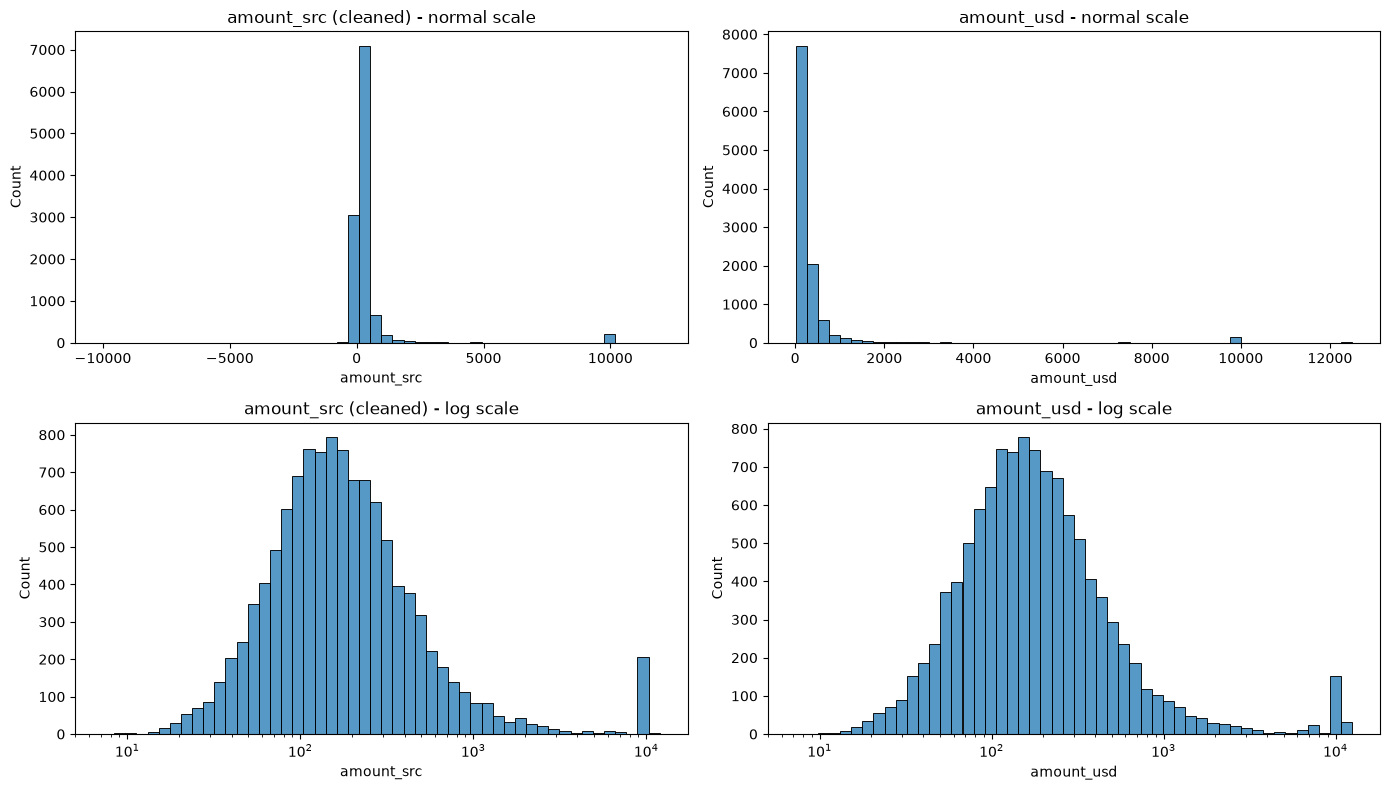

In [48]:
# ------------------------------------------------------------------
# STEP 3: Visualize both distributions side-by-side
# ------------------------------------------------------------------
# Two histograms next to each other let us visually compare shape.
# We also apply a log scale on a second version, since amount data
# is often heavily right-skewed (a few very large transactions
# stretch the x-axis and hide the shape of the bulk of the data).

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: normal scale
sns.histplot(amount_src_numeric.dropna(), bins=50, ax=axes[0, 0])
axes[0, 0].set_title("amount_src (cleaned) - normal scale")

sns.histplot(df["amount_usd"].dropna(), bins=50, ax=axes[0, 1])
axes[0, 1].set_title("amount_usd - normal scale")

# Bottom row: log scale on the x-axis, to reveal shape hidden by outliers
sns.histplot(amount_src_numeric.dropna(), bins=50, ax=axes[1, 0], log_scale=True)
axes[1, 0].set_title("amount_src (cleaned) - log scale")

sns.histplot(df["amount_usd"].dropna(), bins=50, ax=axes[1, 1], log_scale=True)
axes[1, 1].set_title("amount_usd - log scale")

plt.tight_layout()
plt.show()

In [49]:
# ------------------------------------------------------------------
# STEP 4: Check for negative amounts
# ------------------------------------------------------------------
# We noticed negative amount_src values earlier (in the sentinel-value
# sample rows). A transaction amount should logically never be
# negative. Let's quantify how widespread this is, separate from the
# 204 sentinel rows we already investigated - is this ONLY in those
# rows, or does it happen elsewhere too?

negative_amount_src = df[amount_src_numeric < 0]
negative_amount_usd = df[df["amount_usd"] < 0]

print("Rows with negative amount_src:", len(negative_amount_src))
print("Rows with negative amount_usd:", len(negative_amount_usd))

# Check overlap with our previously identified 204 sentinel rows
negative_src_idx = set(negative_amount_src.index)
overlap_with_sentinel = negative_src_idx & common_rows

print("\nOf the negative amount_src rows, how many are ALSO in the sentinel-value group?")
print(len(overlap_with_sentinel), "out of", len(negative_src_idx))

Rows with negative amount_src: 103
Rows with negative amount_usd: 0

Of the negative amount_src rows, how many are ALSO in the sentinel-value group?
103 out of 103


In [50]:
# ------------------------------------------------------------------
# STEP 5: Compare average transaction amount by channel
# ------------------------------------------------------------------
# groupby() splits the data into groups (here, by channel) and lets
# us calculate a summary statistic (mean) for each group separately.
# This helps us see if certain channels typically involve larger or
# smaller transactions - useful context for later feature engineering.
#
# Note: we're using the RAW 'channel' column here, which we know has
# formatting inconsistencies (Section 8) - so treat this as a rough
# look, not a final answer. A clean version belongs in Data Cleaning.

channel_amount_avg = df.groupby("channel")["amount_usd"].mean().sort_values(ascending=False)
print("Average amount_usd by channel (raw, uncleaned categories):")
print(channel_amount_avg)

Average amount_usd by channel (raw, uncleaned categories):
channel
WEB          538.229429
 mobile      506.929362
web          504.278629
mobile       433.744521
ATM          408.445286
mobille      383.841186
ATm          339.755556
weeb         264.212500
 web         208.122353
MOBILE       193.388043
unknown      185.317222
 ATM         110.647500
Name: amount_usd, dtype: float64


### Summary of findings on transaction amount distribution

* amount_src (after temporary comma-cleaning) and amount_usd show similar, plausible right-skewed distributions
* Negative amount_src values (103 rows) are fully explained by the existing sentinel-value finding — not a new issue
* Possible sub-structure within the 204 sentinel rows (roughly two equal-sized groups of ~101-103) — worth a brief mention, low priority
* Channel-based amount comparison is provisional pending categorical cleanup

## 8. Fraud and Legitimate Transactions Distribution

In [51]:
# ------------------------------------------------------------------
# STEP 1: Basic fraud count and proportion
# ------------------------------------------------------------------
# value_counts() gives us raw counts of 0 (legitimate) vs 1 (fraud).
# normalize=True converts these into proportions (percentages) instead
# of raw counts, which is more useful for understanding imbalance.

fraud_counts = df["is_fraud"].value_counts()
fraud_proportions = df["is_fraud"].value_counts(normalize=True) * 100

print("Raw counts:")
print(fraud_counts)

print("\nProportions (%):")
print(fraud_proportions.round(2))

Raw counts:
is_fraud
0    10403
1      997
Name: count, dtype: int64

Proportions (%):
is_fraud
0    91.25
1     8.75
Name: proportion, dtype: float64


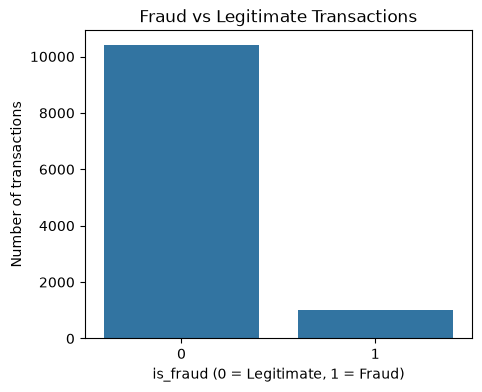

In [52]:
# ------------------------------------------------------------------
# STEP 2: Visualize the class distribution
# ------------------------------------------------------------------
# A simple bar chart makes the imbalance immediately visible - often
# more persuasive in a report than a table of numbers alone.

plt.figure(figsize=(5, 4))
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("is_fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of transactions")
plt.show()

In [53]:
# ------------------------------------------------------------------
# STEP 3: Compare amount_usd for fraud vs legitimate transactions
# ------------------------------------------------------------------
# groupby("is_fraud") splits the data into two groups (0 and 1), then
# .describe() gives us summary statistics for amount_usd within each
# group separately. This lets us see, for example, whether fraud
# transactions tend to be larger, smaller, or similar to legitimate ones.

amount_by_fraud = df.groupby("is_fraud")["amount_usd"].describe()
print("amount_usd summary statistics by fraud status:")
print(amount_by_fraud)

amount_usd summary statistics by fraud status:
            count         mean          std    min      25%     50%      75%  \
is_fraud                                                                       
0         10106.0   395.486364  1378.367659   7.23   88.225  151.50   264.13   
1           989.0  1029.726815  1528.075515  15.98  268.860  545.99  1167.52   

               max  
is_fraud            
0         12498.57  
1         12496.24  


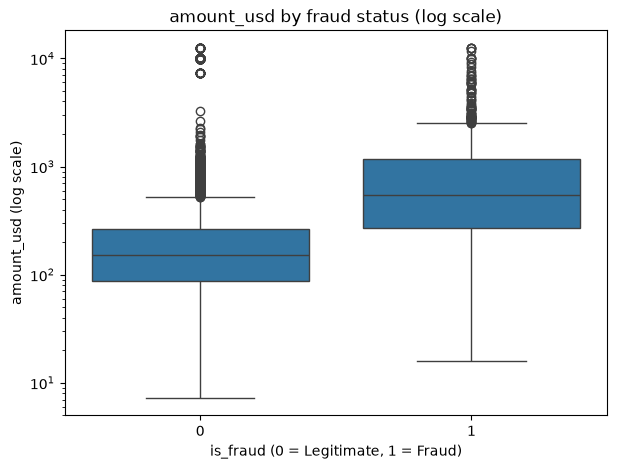

In [54]:
# ------------------------------------------------------------------
# STEP 4: Visualize amount distribution by fraud status
# ------------------------------------------------------------------
# A boxplot side-by-side (one box per class) makes it easy to compare
# medians, spread, and outliers between fraud and legitimate transactions
# at a glance. We use a log scale on amount_usd since we already know
# (Section 10) that transaction amounts are heavily right-skewed.

plt.figure(figsize=(7, 5))
sns.boxplot(x="is_fraud", y="amount_usd", data=df)
plt.yscale("log")
plt.title("amount_usd by fraud status (log scale)")
plt.xlabel("is_fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("amount_usd (log scale)")
plt.show()

In [55]:
# ------------------------------------------------------------------
# STEP 5: Check whether the 204 sentinel rows are disproportionately
# fraud or legitimate
# ------------------------------------------------------------------
# This is an important cross-check: if the sentinel-value rows we
# found earlier turned out to correlate strongly with is_fraud, that
# would be a MAJOR leakage risk (a model could "cheat" by just
# detecting the sentinel pattern instead of learning real fraud
# behaviour). We already saw all 204 rows had is_fraud = 0 in our
# earlier sample - let's confirm that holds for the FULL 204, not
# just the 10-row sample.

sentinel_fraud_rate = df.loc[list(common_rows), "is_fraud"].mean() * 100
overall_fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud rate WITHIN the 204 sentinel rows: {sentinel_fraud_rate:.2f}%")
print(f"Fraud rate in the OVERALL dataset: {overall_fraud_rate:.2f}%")

Fraud rate WITHIN the 204 sentinel rows: 1.96%
Fraud rate in the OVERALL dataset: 8.75%


### Summary of the fraud and legitimate transactions distribution
* How common is fraud in this dataset?
    + Out of 11,400 transactions, 997 (8.75%) are labeled as fraud, and the remaining 10,403 (91.25%) are legitimate. 
    + This is a highly imbalanced dataset — fraud is rare compared to normal activity, which is expected and typical for real-world fraud detection. 
    + This imbalance will need to be specifically accounted for when we build the model (Objective 4), since a model that simply predicts "not fraud" every time would already be right 91% of the time, but would be useless for catching actual fraud.

* Do fraudulent transactions tend to involve different amounts of money?
    + Yes. Fraudulent transactions are, on average, noticeably larger than legitimate ones:

    + The typical (median) fraudulent transaction is $546, compared to $152 for a typical legitimate transaction — roughly 3.6 times larger
    + On average (mean), fraudulent transactions are $1,030 versus $395 for legitimate ones — roughly 2.6 times larger

    + This is an encouraging early sign: transaction amount appears to carry real, useful information for distinguishing fraud from legitimate activity, which supports building the transaction-amount-based features already planned for later stages.

* Does the earlier data quality issue (placeholder values) show up more often in fraud cases?
    + No — and this is an important reassurance. Earlier in profiling, we identified 204 transactions (about 1.8% of the dataset) where several fields contained placeholder values instead of real data, most likely representing missing information that was recorded using fixed stand-in numbers rather than being left blank. 
    + If those 204 transactions were unusually likely to be fraud, it would raise a concern that our model might end up "cheating" — learning to detect the placeholder pattern instead of genuine fraud behavior.

    + We checked this directly: within those 204 transactions, the fraud rate is 1.96% — actually lower than the dataset's overall fraud rate of 8.75%. This means the placeholder-value issue is a data quality problem, not a hidden fraud signal, and it can be safely corrected in the Data Cleaning stage without risk of accidentally removing meaningful fraud information.

## 9. Class Imbalance

In [56]:
# ------------------------------------------------------------------
# STEP 1: Calculate the precise imbalance ratio
# ------------------------------------------------------------------
# We already know the counts from Section 11 (10,403 legitimate,
# 997 fraud). Here we express that as a clean ratio - e.g. "for
# every 1 fraud case, there are X legitimate cases" - which is a
# standard, easily understood way to describe class imbalance.

fraud_count = df["is_fraud"].value_counts()[1]
legit_count = df["is_fraud"].value_counts()[0]

imbalance_ratio = legit_count / fraud_count

print(f"Legitimate transactions: {legit_count}")
print(f"Fraud transactions: {fraud_count}")
print(f"Imbalance ratio (legitimate : fraud): {imbalance_ratio:.2f} : 1")

Legitimate transactions: 10403
Fraud transactions: 997
Imbalance ratio (legitimate : fraud): 10.43 : 1


In [57]:
# ------------------------------------------------------------------
# STEP 2: Calculate what a "do-nothing" baseline model would score
# ------------------------------------------------------------------
# This step demonstrates WHY accuracy is a misleading metric here.
# A "dummy" model that always predicts "not fraud" (0) would still
# achieve high accuracy purely because fraud is rare - not because
# it's actually good at detecting fraud. This is a common and
# important argument to include in a fraud detection project write-up.

dummy_accuracy = legit_count / (legit_count + fraud_count)
print(f"Accuracy of an 'always predict legitimate' baseline model: {dummy_accuracy:.2%}")
print("This score looks impressive but the model would NEVER catch any fraud.")
print("This is exactly why Precision, Recall, and F1-score matter more than Accuracy here (Objective 5).")

Accuracy of an 'always predict legitimate' baseline model: 91.25%
This score looks impressive but the model would NEVER catch any fraud.
This is exactly why Precision, Recall, and F1-score matter more than Accuracy here (Objective 5).


In [58]:
# ------------------------------------------------------------------
# STEP 3: Contextualize the imbalance severity
# ------------------------------------------------------------------
# Different imbalance ratios call for different handling strategies.
# This is just a reference print-out (not a calculation), summarizing
# commonly used rules of thumb, to help frame our imbalance ratio
# in context before deciding on a strategy in Model Development.

print("General reference points for imbalance severity:")
print("- Mild imbalance:     up to about 3:1  -> often no special handling needed")
print("- Moderate imbalance: about 3:1 to 10:1 -> class weighting often sufficient")
print("- Severe imbalance:   beyond 10:1        -> may need SMOTE, undersampling, or a combination")
print(f"\nOur dataset's ratio is {imbalance_ratio:.2f} : 1")

General reference points for imbalance severity:
- Mild imbalance:     up to about 3:1  -> often no special handling needed
- Moderate imbalance: about 3:1 to 10:1 -> class weighting often sufficient
- Severe imbalance:   beyond 10:1        -> may need SMOTE, undersampling, or a combination

Our dataset's ratio is 10.43 : 1


### Summary of findings from class imbalance
* The imbalance ratio is 10.43 : 1 (legitimate to fraud) — meaning for roughly every 10 legitimate transactions, there is 1 fraudulent one. Using the reference bands, this sits right at the boundary between "moderate" and "severe" imbalance (the general convention places the line at 10:1). This is a meaningful, real piece of context: it tells us we shouldn't rely on class weighting alone as a safe default — we should evaluate both class weighting and SMOTE (or a combination) empirically in Model Development, per Objective 4, rather than assuming one is clearly sufficient.

* Why this matters for model evaluation (plain-language version for stakeholders): if we built a model that simply predicted "not fraud" for every single transaction, it would be 91.25% accurate — yet it would catch zero fraud cases. This demonstrates concretely why accuracy alone is a misleading metric for this project, and why Precision, Recall, F1-score, and the Confusion Matrix (Objective 5) are the metrics that actually matter here. A high-accuracy model that misses all fraud is worse than useless — it creates false confidence.

* Implication for modelling strategy: given the 10.43:1 ratio falls at the edge of "moderate/severe," we'll want to test:

* Class weighting (simpler, often a reasonable first attempt at this ratio)
* SMOTE (synthetic oversampling of the minority class)
* Possibly a comparison of both, since neither is guaranteed to be clearly superior at this exact ratio without empirical testing

## 10. Identifier uniqueness

In [59]:
# ------------------------------------------------------------------
# STEP 1: Re-confirm the basic uniqueness counts from Data Understanding
# ------------------------------------------------------------------
# We already know these numbers from Data Understanding (Section 14
# of your handoff), but we recalculate them here directly in this
# notebook so the profiling notebook is self-contained and doesn't
# rely on numbers from a different notebook.

id_cols = ["transaction_id", "customer_id", "device_id", "ip_address"]

for col in id_cols:
    total = len(df)
    unique = df[col].nunique()
    print(f"{col}: {unique} unique values out of {total} total rows")

transaction_id: 11200 unique values out of 11400 total rows
customer_id: 1315 unique values out of 11400 total rows
device_id: 2113 unique values out of 11400 total rows
ip_address: 10900 unique values out of 11400 total rows


In [60]:
# ------------------------------------------------------------------
# STEP 2: Check how many DIFFERENT customers share each device
# ------------------------------------------------------------------
# groupby("device_id") groups all rows by device, then for each group
# we count the number of UNIQUE customer_ids that used that device.
# A device used by only 1 customer is normal (personal phone/computer).
# A device used by MANY different customers is unusual and worth a
# closer look - could indicate shared/family devices, or potentially
# fraud rings using the same device across fake accounts.

customers_per_device = df.groupby("device_id")["customer_id"].nunique().sort_values(ascending=False)

print("Top 10 devices by number of distinct customers using them:")
print(customers_per_device.head(10))

print("\nDistribution summary of customers-per-device:")
print(customers_per_device.describe())

Top 10 devices by number of distinct customers using them:
device_id
00159b7f-8fad-45e4-b66d-72bfc2e759be    1
0015b9fa-5fe1-4596-9511-f4cec80d2b6a    1
00278980-701d-4103-ae94-26a7fe26be7c    1
0034bc9f-1a9d-471e-a162-52d315b5f55f    1
00599d65-faa5-4ace-851a-18535cda9133    1
00a218c1-797f-427e-b369-4ac24195406b    1
00cfd083-289d-4583-9d1b-704417a347c2    1
013efa93-3aee-4a52-9ab8-d58e0078591b    1
01e18a33-3287-4ada-8581-6cd1c039e480    1
01e74075-c3bd-455c-bd1f-71153b9a414c    1
Name: customer_id, dtype: int64

Distribution summary of customers-per-device:
count    2113.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: customer_id, dtype: float64


In [61]:
# ------------------------------------------------------------------
# STEP 3: Check how many DIFFERENT customers share each IP address
# ------------------------------------------------------------------
# Same logic as Step 2, but for ip_address instead of device_id.
# Many customers sharing one IP could indicate a shared network
# (e.g. office, university), OR could indicate suspicious activity
# (e.g. many fake accounts operated from one location).

customers_per_ip = df.groupby("ip_address")["customer_id"].nunique().sort_values(ascending=False)

print("Top 10 IP addresses by number of distinct customers using them:")
print(customers_per_ip.head(10))

print("\nDistribution summary of customers-per-IP:")
print(customers_per_ip.describe())

Top 10 IP addresses by number of distinct customers using them:
ip_address
1.100.216.122    1
1.104.115.81     1
1.105.176.49     1
1.108.58.45      1
1.109.137.153    1
1.124.141.253    1
1.129.143.139    1
1.146.96.60      1
1.147.138.1      1
1.147.215.98     1
Name: customer_id, dtype: int64

Distribution summary of customers-per-IP:


count    10900.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: customer_id, dtype: float64


In [62]:
# ------------------------------------------------------------------
# STEP 4: Check transaction frequency per customer
# ------------------------------------------------------------------
# This tells us the range of activity levels across customers - are
# most customers making just a few transactions, or do some customers
# have an unusually high number of transactions compared to everyone
# else? This is useful context for later feature engineering
# (customer_transaction_count) and for spotting anything extreme.

txns_per_customer = df.groupby("customer_id").size().sort_values(ascending=False)

print("Top 10 customers by transaction count:")
print(txns_per_customer.head(10))

print("\nDistribution summary of transactions-per-customer:")
print(txns_per_customer.describe())

Top 10 customers by transaction count:
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
7bd5200c-5d19-44f0-9afe-8b339a05366b     811
70a93d26-8e3a-4179-900c-a4a7a74d08e5     677
f7531a78-8bbe-4a85-b1e8-a0650edddc72     394
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     360
23d9943d-57b1-42eb-9ef2-05eed7fd1957     347
dtype: int64

Distribution summary of transactions-per-customer:
count    1315.000000
mean        8.669202
std        84.766961
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      1510.000000
dtype: float64


In [63]:
# ------------------------------------------------------------------
# STEP 5: Cross-check - do the highest-sharing devices/IPs correlate
# with fraud?
# ------------------------------------------------------------------
# This is the most important question in this section: if a device
# or IP is used by many different customers, are transactions from
# that device/IP more likely to be fraudulent? We check this for the
# top 5% most-shared devices as a starting point.

# Identify devices used by more than 1 customer (i.e. shared devices)
shared_devices = customers_per_device[customers_per_device > 1].index
shared_device_txns = df[df["device_id"].isin(shared_devices)]

fraud_rate_shared_device = shared_device_txns["is_fraud"].mean() * 100
fraud_rate_overall = df["is_fraud"].mean() * 100

print(f"Fraud rate on transactions from SHARED devices: {fraud_rate_shared_device:.2f}%")
print(f"Fraud rate OVERALL: {fraud_rate_overall:.2f}%")
print(f"Number of transactions involving a shared device: {len(shared_device_txns)}")

Fraud rate on transactions from SHARED devices: nan%
Fraud rate OVERALL: 8.75%
Number of transactions involving a shared device: 0


In [64]:
# ------------------------------------------------------------------
# Check whether high-frequency customers have a different fraud rate
# than low-frequency customers
# ------------------------------------------------------------------
# We split customers into two groups: "frequent" (more than 1
# transaction) and "one-time" (exactly 1 transaction), then compare
# the fraud rate between these groups. This replaces our original
# Step 5 plan, since device/IP sharing turned out not to exist.

# Map each transaction to its customer's total transaction count
df["customer_txn_count"] = df["customer_id"].map(txns_per_customer)

# Split into one-time vs frequent customers
one_time_txns = df[df["customer_txn_count"] == 1]
frequent_txns = df[df["customer_txn_count"] > 1]

fraud_rate_one_time = one_time_txns["is_fraud"].mean() * 100
fraud_rate_frequent = frequent_txns["is_fraud"].mean() * 100

print(f"Number of one-time-customer transactions: {len(one_time_txns)}")
print(f"Number of frequent-customer transactions: {len(frequent_txns)}")
print(f"\nFraud rate among ONE-TIME customers: {fraud_rate_one_time:.2f}%")
print(f"Fraud rate among FREQUENT customers:  {fraud_rate_frequent:.2f}%")
print(f"Overall fraud rate:                   {df['is_fraud'].mean() * 100:.2f}%")

Number of one-time-customer transactions: 1239
Number of frequent-customer transactions: 10161

Fraud rate among ONE-TIME customers: 64.57%
Fraud rate among FREQUENT customers:  1.94%
Overall fraud rate:                   8.75%


In [65]:
# ------------------------------------------------------------------
# Look specifically at the fraud rate for the TOP 10 highest-frequency
# customers, since they're the most extreme cases
# ------------------------------------------------------------------

top_10_customers = txns_per_customer.head(10).index
top_10_txns = df[df["customer_id"].isin(top_10_customers)]

print("Fraud rate for each of the top 10 highest-frequency customers:")
print(top_10_txns.groupby("customer_id")["is_fraud"].agg(["count", "mean"]).sort_values("count", ascending=False))

Fraud rate for each of the top 10 highest-frequency customers:
                                      count      mean
customer_id                                          
402cccc9-28de-45b3-9af7-cc5302aa1f93   1510  0.008609
d71c91b4-fee8-4104-9856-a5c6109a62e3   1355  0.021402
7041b9c1-3719-4ca8-9a6b-811b47cea6c0   1345  0.066171
6d0d9b27-fa26-45f8-93b1-2df29d182d9c   1066  0.001876
af8ca4c4-8703-4c55-b66c-2b76cd70040d    915  0.014208
7bd5200c-5d19-44f0-9afe-8b339a05366b    811  0.013564
70a93d26-8e3a-4179-900c-a4a7a74d08e5    677  0.005908
f7531a78-8bbe-4a85-b1e8-a0650edddc72    394  0.010152
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad    360  0.013889
23d9943d-57b1-42eb-9ef2-05eed7fd1957    347  0.000000


In [66]:
# ------------------------------------------------------------------
# Compare amount_usd for one-time customers, split by fraud status
# ------------------------------------------------------------------
# If one-time-customer fraud looks like classic "hit and run" fraud,
# we'd expect those fraudulent transactions to also tend to be large
# amounts, consistent with what we found in Section 11 for fraud
# overall. This helps us judge whether the pattern is behaviorally
# plausible or looks more like an artificial labeling rule.

one_time_amount_by_fraud = one_time_txns.groupby("is_fraud")["amount_usd"].describe()
print("amount_usd for ONE-TIME customers, by fraud status:")
print(one_time_amount_by_fraud)

amount_usd for ONE-TIME customers, by fraud status:
          count         mean          std    min       25%     50%        75%  \
is_fraud                                                                        
0         439.0   189.030023   142.754987  19.03   92.8500  156.00   238.6550   
1         800.0  1091.352350  1274.313944  74.00  372.7175  672.89  1283.7675   

               max  
is_fraud            
0          1058.47  
1         11691.12  


In [67]:
# ------------------------------------------------------------------
# Check channel and kyc_tier patterns for one-time customers
# ------------------------------------------------------------------
# If one-time fraud is concentrated in a specific channel or KYC tier
# (e.g. mostly "low" KYC tier, or mostly one channel), that would be
# a plausible, explainable real-world pattern (weaker verification =
# easier to commit fraud and disappear). If it's evenly spread with
# no explanation, that's more suspicious of an artificial pattern.

print("Channel distribution for one-time FRAUD transactions:")
print(one_time_txns[one_time_txns["is_fraud"] == 1]["channel"].value_counts())

print("\nKYC tier distribution for one-time FRAUD transactions:")
print(one_time_txns[one_time_txns["is_fraud"] == 1]["kyc_tier"].value_counts(dropna=False))

Channel distribution for one-time FRAUD transactions:
channel
web       532
mobile    200
ATM        68
Name: count, dtype: int64

KYC tier distribution for one-time FRAUD transactions:
kyc_tier
low         519
standard    247
enhanced     34
Name: count, dtype: int64


### Summary of identfier uniquness findings
* One-time customers show a 64.57% fraud rate versus 1.94% for repeat customers — a striking difference supported by corroborating evidence: one-time fraud transactions are markedly larger ($1,091 mean vs. $189 for one-time legitimate transactions) and disproportionately associated with low KYC tier accounts (65%), both consistent with genuine "open account, commit fraud once, disappear" behavior rather than a dataset artifact.

* However, this creates a significant data leakage risk if implemented naively. A customer_transaction_count feature computed over the customer's entire transaction history (including transactions after the one being predicted) would only be able to identify "one-time customers" by using future information unavailable at prediction time. Any customer-frequency feature must instead be computed using only transactions prior to the current one (time-aware / point-in-time logic), consistent with the caution already raised in the project handoff regarding customer_id-derived features (Section 19) and risk_score_internal (Section 20). This will be a key design constraint in Feature Engineering.

* Device/IP sharing, meanwhile, was found not to exist in this dataset (every device and IP maps to exactly one customer) — so those particular planned features (Section 29) can be deprioritized or dropped.

## 11. Potential data leakage

In [68]:
# ------------------------------------------------------------------
# STEP 1: Check correlation between all numeric features and is_fraud
# ------------------------------------------------------------------
# Correlation measures how strongly two variables move together.
# A value close to +1 or -1 means a very strong relationship.
# For genuine, honest predictors, we usually expect moderate
# correlations. A SUSPICIOUSLY high correlation (e.g. above 0.7-0.8)
# with the target variable is a classic warning sign of leakage -
# it can mean the variable was calculated using information from
# after the fraud was already known/investigated.

numeric_cols_for_corr = df.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

correlations = df[numeric_cols_for_corr].corr()["is_fraud"].sort_values(ascending=False)
print("Correlation of each numeric variable with is_fraud:")
print(correlations)

Correlation of each numeric variable with is_fraud:
is_fraud                     1.000000
txn_velocity_24h             0.750092
txn_velocity_1h              0.686235
risk_score_internal          0.601174
chargeback_history_count     0.580136
ip_risk_score                0.518930
location_mismatch            0.416710
new_device                   0.376999
corridor_risk                0.192821
year                         0.154501
exchange_rate_src_to_dest    0.152035
amount_usd                   0.128729
fee                         -0.014256
account_age_days            -0.284191
customer_txn_count          -0.356285
device_trust_score          -0.390952
Name: is_fraud, dtype: float64


In [69]:
# ------------------------------------------------------------------
# STEP 2: Investigate risk_score_internal specifically
# ------------------------------------------------------------------
# The project handoff flagged this column as a leakage
# concern: was this score calculated BEFORE or AFTER the fraud
# outcome was known? We can't determine "when" it was calculated
# just from the data, but we CAN check how strongly it relates to
# is_fraud, and look at its distribution by fraud status - a very
# clean separation between fraud/legitimate would be a red flag.

risk_score_by_fraud = df.groupby("is_fraud")["risk_score_internal"].describe()
print("risk_score_internal by fraud status:")
print(risk_score_by_fraud)

risk_score_internal by fraud status:
            count      mean       std    min    25%    50%     75%    max
is_fraud                                                                 
0         10403.0  0.240524  0.101994  0.000  0.166  0.223  0.2935  0.554
1           997.0  0.544783  0.201920  0.029  0.407  0.538  0.7100  0.900


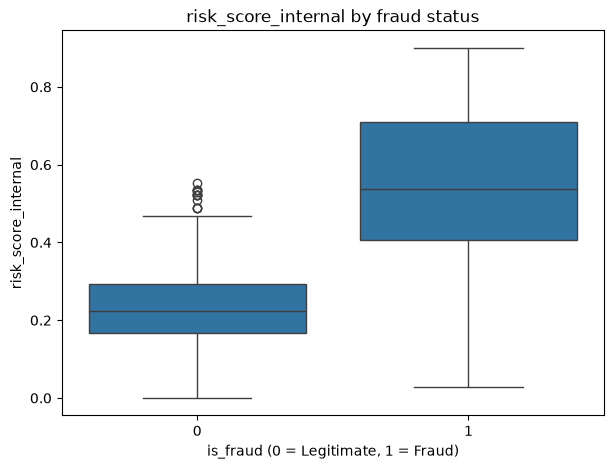

In [70]:
# ------------------------------------------------------------------
# STEP 3: Visualize risk_score_internal separation between classes
# ------------------------------------------------------------------
# If fraud and legitimate transactions have almost NO overlap in
# their risk_score_internal values (e.g. all fraud > 0.5 and all
# legitimate < 0.5), that would strongly suggest this score was
# built using knowledge of the fraud outcome - i.e. leakage.
# Genuine, honestly-computed risk scores usually show SOME overlap,
# since no single feature perfectly predicts fraud on its own.

plt.figure(figsize=(7, 5))
sns.boxplot(x="is_fraud", y="risk_score_internal", data=df)
plt.title("risk_score_internal by fraud status")
plt.xlabel("is_fraud (0 = Legitimate, 1 = Fraud)")
plt.show()

In [71]:
# ------------------------------------------------------------------
# STEP 4: Re-confirm the customer_transaction_count leakage risk, alongside the other velocity/risk variables
# ------------------------------------------------------------------
# This consolidates what we already found: customer-level transaction
# counts (if computed across full history) show a very strong
# relationship with fraud, but only because they use future
# information. We print it here alongside the correlation table
# from Step 1 for direct comparison in the same section.

count_corr = df[["customer_txn_count", "is_fraud"]].corr().iloc[0, 1]
print(f"Correlation between customer_txn_count (full-history, NOT time-aware) and is_fraud: {count_corr:.3f}")

Correlation between customer_txn_count (full-history, NOT time-aware) and is_fraud: -0.356


### Summary of the findings on potential data leakage
* Several numeric variables show correlations with is_fraud far higher than typically expected for honest, pre-transaction fraud predictors: txn_velocity_24h (0.75), txn_velocity_1h (0.69), risk_score_internal (0.60), chargeback_history_count (0.58), and ip_risk_score (0.52). For comparison, plausible real-world indicators in this dataset (location_mismatch, new_device, amount_usd) show more moderate correlations (0.13–0.42), consistent with genuine but imperfect fraud signals.

* risk_score_internal shows a mean of 0.54 for fraud vs. 0.24 for legitimate transactions, with substantial (but not complete) overlap between distributions. This is consistent with — though not definitive proof of — the leakage concern already raised in the project's Data Understanding phase regarding this variable's provenance.

* customer_txn_count, when computed using a customer's full transaction history, shows a correlation of -0.356 with fraud, driven by the one-time-customer pattern identified in Section 13. This confirms the earlier finding and reinforces that this feature is unsafe to use in its current (non-time-aware) form.

* Recommendation for Feature Engineering/Model Development: risk_score_internal, txn_velocity_1h/24h, chargeback_history_count, and ip_risk_score should be treated as high-risk for leakage pending further investigation into how and when they were computed. customer_txn_count and any similar identifier-derived aggregate must be rebuilt using time-aware (point-in-time) logic before use. In the absence of definitive provenance information, the cautious default is to exclude or heavily scrutinize these variables rather than assume they are safe.

In [72]:
# ------------------------------------------------------------------
# Re-confirm timestamp missing count on the CURRENT working dataframe
# ------------------------------------------------------------------
# We want to resolve a discrepancy: an earlier check found 29 missing
# timestamps, but an earlier section of this same notebook found 61. We check
# directly, on the exact dataframe we've been using throughout this
# session, to see which number is correct for our current data.

print("Current df shape:", df.shape)
print("timestamp missing count (current df):", df["timestamp"].isnull().sum())

Current df shape: (11400, 29)
timestamp missing count (current df): 61


In [73]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Dataset"
    / "raw"
    / "FinLora_Customer_Transaction_Dataset.csv"
)

df_fresh = pd.read_csv(DATA_PATH)

print("Fresh reload shape:", df_fresh.shape)
print("Fresh reload timestamp missing count:", df_fresh["timestamp"].isnull().sum())

Fresh reload shape: (11400, 26)
Fresh reload timestamp missing count: 29


In [74]:
# ------------------------------------------------------------------
# Find EXACTLY which rows became newly-missing in our working df
# ------------------------------------------------------------------
# We compare the fresh, untouched reload against our current working
# df, row by row (using the same index), to find which specific rows
# had a valid timestamp originally but are now missing in df.

# Align on transaction_id in case row order differs (safer than raw index)
fresh_ts = df_fresh.set_index("transaction_id")["timestamp"]
current_ts = df.set_index("transaction_id")["timestamp"]

# Rows where the fresh copy has a value, but our current df is now null
newly_missing = current_ts[(current_ts.isnull()) & (fresh_ts.notnull())]

print("Number of newly-missing timestamp rows:", len(newly_missing))
print("\nSample of affected transaction_ids:")
print(newly_missing.head(10))

Number of newly-missing timestamp rows: 32

Sample of affected transaction_ids:
transaction_id
d36a0593-5a44-4174-a5ed-cc7317bc8524   NaT
7f3f5c09-b75c-4355-aca4-d70e169d6df6   NaT
3d21deb2-a290-474e-9cd4-664294f0fa69   NaT
5487dc9b-4f24-4b76-a0d5-c2f0b94bd155   NaT
277ae243-8d24-49e1-9938-185551be6e05   NaT
b79f933f-272d-49bf-bf4b-b2b6ed5662ab   NaT
f8474028-9a70-4df5-b9f5-87541cf9bf65   NaT
545094a5-5d3f-495a-8df0-f697f37bb414   NaT
8e26f846-c088-4c10-9410-613e06bc61b1   NaT
b1018d49-8b60-43ba-9e8f-712e16aeacb9   NaT
Name: timestamp, dtype: datetime64[ns, UTC]


In [75]:
# ------------------------------------------------------------------
# Inspect what the ORIGINAL (fresh) values looked like for these
# specific transaction_ids, to see if there's a pattern
# ------------------------------------------------------------------
# This shows us the actual original timestamp text for the rows that
# somehow became null in our working df - which might reveal a clue
# about what happened (e.g. a specific unusual formatting that some
# earlier operation mishandled).

affected_ids = newly_missing.index[:10]
print("Original (fresh) timestamp values for affected rows:")
print(df_fresh[df_fresh["transaction_id"].isin(affected_ids)][["transaction_id", "timestamp"]])

Original (fresh) timestamp values for affected rows:
                            transaction_id             timestamp
40    d36a0593-5a44-4174-a5ed-cc7317bc8524   2025/13/40 25:61:00
210   7f3f5c09-b75c-4355-aca4-d70e169d6df6  0000-00-00T00:00:00Z
1958  3d21deb2-a290-474e-9cd4-664294f0fa69  0000-00-00T00:00:00Z
2224  5487dc9b-4f24-4b76-a0d5-c2f0b94bd155  0000-00-00T00:00:00Z
2462  277ae243-8d24-49e1-9938-185551be6e05  0000-00-00T00:00:00Z
2480  b79f933f-272d-49bf-bf4b-b2b6ed5662ab  0000-00-00T00:00:00Z
2981  f8474028-9a70-4df5-b9f5-87541cf9bf65  0000-00-00T00:00:00Z
3982  545094a5-5d3f-495a-8df0-f697f37bb414  0000-00-00T00:00:00Z
4193  8e26f846-c088-4c10-9410-613e06bc61b1   2025/13/40 25:61:00
4593  b1018d49-8b60-43ba-9e8f-712e16aeacb9   2025/13/40 25:61:00


### Summary of findings on missingess

* Standard .isnull() checks show timestamp with 29 missing values. 
* However, deeper validation (attempting to parse every value as a real date) reveals an additional 32 rows containing syntactically invalid or placeholder timestamp text (e.g. "0000-00-00T00:00:00Z", "2025/13/40 25:61:00") that are not caught by .isnull() but are equally unusable. 
* The true count of missing-or-invalid timestamps is 61, not 29. 
* This is the third instance in this dataset of missingness being disguised in a form that evades naive null-checking.

# SUMMARY OF DATA QUALITY ISSUE

### 1. Duplicate Records
- 200 transaction_ids appear exactly twice each (400 rows total)
- Confirmed as exact duplicates across all columns (no differing values)
- Not yet removed — reserved for Data Cleaning

### 2. Disguised Missing Values (three distinct forms found)
Standard `.isnull()` checks understate true missingness in this dataset. Three separate
disguised-missingness patterns were identified:

  a) Placeholder/sentinel numeric values — 204 rows (1.8% of dataset) contain a
     coordinated pattern across four columns:
       - ip_risk_score = 1.2 (outside valid 0–1 range)
       - device_trust_score = -0.1 (outside valid 0–1 range)
       - txn_velocity_1h = -1 (logically impossible, a count cannot be negative)
       - fee = 9999.99 or -1.00 (two sub-groups of ~101–103 rows each)
     Also associated with negative amount_src values (103 rows) and occasional NaN in
     amount_usd/kyc_tier for the same rows. Disproportionately associated with the
     'web' channel (61% vs. 30% baseline) but not associated with home_country or
     transaction date. Fraud rate within these rows (1.96%) is below the dataset
     baseline (8.75%), ruling out a direct leakage relationship with the target variable.

  b) Literal "NaN"-style text strings — 6 rows total: 3 in ip_country, 3 in kyc_tier
     (values like "NaN", "NAN", " nan"), separate from and in addition to true null values.

  c) Malformed/placeholder timestamp text — 32 rows contain syntactically invalid
     timestamp strings (e.g. "0000-00-00T00:00:00Z", "2025/13/40 25:61:00") that pass
     as non-null text but fail datetime parsing.

### 3. Standard Missing Values (true NaN, confirmed on fresh data reload)
| Column               | Missing | %     |
|---------------------|---------|-------|
| amount_usd           | 305     | 2.68% |
| ip_address           | 305     | 2.68% |
| ip_country           | 301     | 2.64% |
| kyc_tier             | 300     | 2.63% |
| device_trust_score   | 295     | 2.59% |
| fee                  | 295     | 2.59% |
| timestamp            | 29 (true NaN); 61 total including malformed text (see 2c) |

### 4. Data Type Issues
- amount_src stored as object/text instead of numeric, due to 4 rows using comma
  thousands-separators (e.g. "9,998.85"). Resolves cleanly once commas are stripped.
- timestamp stored as object/text instead of datetime. Converts cleanly aside from the
  32 malformed rows noted above.

### 5. Categorical Inconsistencies
- channel: casing/whitespace/typo variants (MOBILE, mobille, weeb, ATm, etc.) collapse
  to 3 canonical categories (mobile, web, ATM); includes an "unknown" category (37 rows)
- home_country: whitespace variants (" US", " UK", " CA"); "unknown" category (32 rows)
- ip_country: same whitespace pattern; "unknown" category (33 rows); see also 2b
- kyc_tier: casing/whitespace/typo variants (STANDARD, standrd, enhancd, etc.) collapse
  to 3 canonical tiers (low, standard, enhanced); "unknown" category (32 rows); see also 2b
- source_currency, dest_currency, new_device, location_mismatch: confirmed clean, no
  issues found

### 6. Outlier / Distribution Notes
- IQR-based outlier detection is unreliable for zero-inflated variables
  (txn_velocity_1h/24h, chargeback_history_count) and naturally skewed variables
  (amount_usd, fee, exchange_rate_src_to_dest) — high IQR "outlier counts" for these
  columns reflect expected distribution shape, not necessarily bad data
- is_fraud must be excluded from any numeric outlier/distribution analysis, as it is
  the binary target variable, not a continuous feature

### 7. Class Imbalance
- 8.75% fraud vs. 91.25% legitimate (10.43 : 1 ratio) — sits at the boundary between
  "moderate" and "severe" imbalance by standard reference bands
- A naive "always predict legitimate" baseline would score 91.25% accuracy while
  catching zero fraud — reinforces why Precision/Recall/F1/Confusion Matrix (not
  Accuracy) must be the primary evaluation metrics (Objective 5)

### 8. Identifier Integrity
- No device_id or ip_address is shared across more than one customer_id — device/IP
  sharing does not exist in this dataset; planned features relying on this
  (e.g. device_customer_count) will provide no signal and can be deprioritized
- Transaction frequency per customer is highly skewed: 75% of customers made only
  1 transaction, while the top customer made 1,510. Mean (8.67) is dwarfed by std
  (84.77), confirming extreme skew

### 9. Potential Data Leakage — HIGH PRIORITY
  a) One-time customers show a 64.57% fraud rate vs. 1.94% for repeat customers
     (33x difference). Supporting evidence (larger amounts, lower KYC tier
     concentration) suggests the underlying behavioral pattern is genuine
     ("hit and run" fraud). However, any customer_transaction_count feature computed
     over a customer's FULL history (including future transactions) constitutes
     leakage, since it requires knowledge unavailable at prediction time. Must be
     rebuilt using time-aware (point-in-time) logic in Feature Engineering.

  b) Several numeric variables show correlations with is_fraud far higher than
     typical for honest pre-transaction predictors:
       - txn_velocity_24h: 0.750
       - txn_velocity_1h: 0.686
       - risk_score_internal: 0.601
       - chargeback_history_count: 0.580
       - ip_risk_score: 0.519
     For comparison, plausible real-world indicators (location_mismatch, new_device,
     amount_usd) show more moderate correlations (0.13–0.42). risk_score_internal
     shows substantial mean separation between fraud (0.54) and legitimate (0.24)
     transactions with only partial distribution overlap.
     Provenance (when/how these were calculated relative to the fraud outcome) could
     not be determined from the data alone, consistent with the concern already
     raised in Data Understanding. Recommendation: treat as high-risk pending further
     investigation; default to caution (exclude or heavily scrutinize) rather than
     assume safety, per project principle of not inventing unverified business rules.

### 10. General Methodological Note
This dataset systematically under-reports missingness through naive null-checking.
Three independent instances of disguised missingness were found across different
columns and formats (numeric placeholders, text placeholders, malformed dates).
Any future missing-value handling in this project should validate columns individually
rather than relying solely on `.isnull().sum()`.